# Problem Statement
Imagine a scaling digital media agency or a tech hub in Jaipur. They have creators editing heavy 4K videos in DaVinci Resolve, engineers deploying automation scripts, and server infrastructure to maintain. When a creator's computer crashes, or ManyChat triggers fail, they raise an IT Support Ticket. If the IT team takes too long to fix it, the creator misses their upload schedule, ruining their viral growth loop and costing the company sponsorship revenue.
This project will clean up missing tracking values, evaluate team performance against a Service Level Agreement (SLA), and build a high-level dashboard to show management exactly where the bottlenecks are.
The goal is to measure how efficiently an IT support team resolves issues and identify where delays are happening.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# IT Helpdesk Operational logs
production_logs = {
    'Ticket_ID' : [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008],
    'Department' : ['Video Editing', 'IT Infrastructure', 'Social Automation', 'Video Editing', 
                   'IT Infrastructure', 'Social Automation', 'Video Editing', 'IT Infrastructure'],
    'Issue_Type' : ['DaVinci GPU Crash', 'RedHat Server Offline', 'ManyChat Trigger Failure', 
                  'Render Queue Freeze', 'Samba Share Network Drop', 'Earnly API Auth Timeout', 
                  'Proxy Drive Disconnect', 'SSH Key Rotation Lock'],
    'Resolution_Time_Hours' : [2.5, np.nan, 1.2, 4.0, 6.5, np.nan, 3.1, 1.8],
    'Impact_Score_1to5' : [4, 5, 3, 4, 5, 2, np.nan, 3],
    'Sponsorship_At_Risk_INR' : [50000, 120000, 30000, 50000, 0, 15000, 45000, 0]
}

df_tickets = pd.DataFrame(production_logs)
df_tickets

,Ticket_ID,Department,Issue_Type,Resolution_Time_Hours,Impact_Score_1to5,Sponsorship_At_Risk_INR
0,1001,Video Editing,DaVinci GPU Crash,2.5,4.0,50000
1,1002,IT Infrastructure,RedHat Server Offline,NaN,5.0,120000
2,1003,Social Automation,ManyChat Trigger Failure,1.2,3.0,30000
3,1004,Video Editing,Render Queue Freeze,4.0,4.0,50000
4,1005,IT Infrastructure,Samba Share Network Drop,6.5,5.0,0
5,1006,Social Automation,Earnly API Auth Timeout,NaN,2.0,15000
6,1007,Video Editing,Proxy Drive Disconnect,3.1,NaN,45000
7,1008,IT Infrastructure,SSH Key Rotation Lock,1.8,3.0,0


In [10]:
# Give missing values
print(df_tickets.isnull().sum())

Ticket_ID                  0
Department                 0
Issue_Type                 0
Resolution_Time_Hours      2
Impact_Score_1to5          1
Sponsorship_At_Risk_INR    0
dtype: int64


In [11]:
median_time = df_tickets['Resolution_Time_Hours'].median()
df_tickets['Resolution_Time_Hours'] = df_tickets['Resolution_Time_Hours'].fillna(median_time)
df_tickets

,Ticket_ID,Department,Issue_Type,Resolution_Time_Hours,Impact_Score_1to5,Sponsorship_At_Risk_INR
0,1001,Video Editing,DaVinci GPU Crash,2.5,4.0,50000
1,1002,IT Infrastructure,RedHat Server Offline,2.8,5.0,120000
2,1003,Social Automation,ManyChat Trigger Failure,1.2,3.0,30000
3,1004,Video Editing,Render Queue Freeze,4.0,4.0,50000
4,1005,IT Infrastructure,Samba Share Network Drop,6.5,5.0,0
5,1006,Social Automation,Earnly API Auth Timeout,2.8,2.0,15000
6,1007,Video Editing,Proxy Drive Disconnect,3.1,NaN,45000
7,1008,IT Infrastructure,SSH Key Rotation Lock,1.8,3.0,0


# Mean, Mode & Median
Mean = Avg = Sum of all values/ Total number of values.
When to use it:- Use the Mean when your data is stable, consistent, and evenly distributed.

Median = Middle value of your dataset.
Example:- [3,4,4,5,6,8,26] so, Median = 5
When to use it:- When the data has extreme highs or lows.

Mode = Most frequent value/ most repeated value in the dataset. 
Example:- [3,4,4,5,6,8,26] so, Mode = 4 
When to use it:- The Mode is incredibly powerful when dealing with categorical data (text strings) where you cannot do math.

In [15]:
# Drop the row completely where the impact score was never recorded
df_tickets.dropna(subset = ['Impact_Score_1to5'], inplace = True)
df_tickets

,Ticket_ID,Department,Issue_Type,Resolution_Time_Hours,Impact_Score_1to5,Sponsorship_At_Risk_INR
0,1001,Video Editing,DaVinci GPU Crash,2.5,4.0,50000
1,1002,IT Infrastructure,RedHat Server Offline,2.8,5.0,120000
2,1003,Social Automation,ManyChat Trigger Failure,1.2,3.0,30000
3,1004,Video Editing,Render Queue Freeze,4.0,4.0,50000
4,1005,IT Infrastructure,Samba Share Network Drop,6.5,5.0,0
5,1006,Social Automation,Earnly API Auth Timeout,2.8,2.0,15000
7,1008,IT Infrastructure,SSH Key Rotation Lock,1.8,3.0,0


In [16]:
# Create a new column named as 'Risk Weight Index'
df_tickets['Risk_Weight_Index'] = df_tickets['Impact_Score_1to5'] * df_tickets['Sponsorship_At_Risk_INR']
df_tickets

,Ticket_ID,Department,Issue_Type,Resolution_Time_Hours,Impact_Score_1to5,Sponsorship_At_Risk_INR,Risk_Weight_Index
0,1001,Video Editing,DaVinci GPU Crash,2.5,4.0,50000,200000.0
1,1002,IT Infrastructure,RedHat Server Offline,2.8,5.0,120000,600000.0
2,1003,Social Automation,ManyChat Trigger Failure,1.2,3.0,30000,90000.0
3,1004,Video Editing,Render Queue Freeze,4.0,4.0,50000,200000.0
4,1005,IT Infrastructure,Samba Share Network Drop,6.5,5.0,0,0.0
5,1006,Social Automation,Earnly API Auth Timeout,2.8,2.0,15000,30000.0
7,1008,IT Infrastructure,SSH Key Rotation Lock,1.8,3.0,0,0.0


In [17]:
# System Diversity Audit
print('Total Unique Operational Departments:', df_tickets['Department'].nunique())
print('Unique types of Infrastructure Issues Logged:', df_tickets['Issue_Type'].unique())

Total Unique Operational Departments: 3
Unique types of Infrastructure Issues Logged: <StringArray>
[       'DaVinci GPU Crash',    'RedHat Server Offline',
 'ManyChat Trigger Failure',      'Render Queue Freeze',
 'Samba Share Network Drop',  'Earnly API Auth Timeout',
    'SSH Key Rotation Lock']
Length: 7, dtype: str


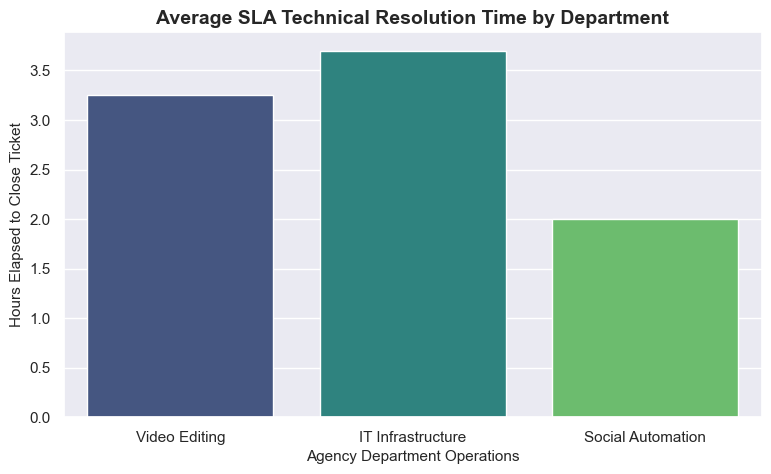

In [22]:
sns.set_theme(style = 'darkgrid')
plt.figure(figsize = (9,5))
sns.barplot(
    data = df_tickets,
    x = 'Department',
    y = 'Resolution_Time_Hours',
    hue = 'Department',
    palette = 'viridis',
    legend = False, # Don't show what different color bars representing.
    errorbar = None 
)

plt.title('Average SLA Technical Resolution Time by Department', fontsize=14, fontweight='bold')
plt.xlabel('Agency Department Operations', fontsize=11)
plt.ylabel('Hours Elapsed to Close Ticket', fontsize=11)
plt.show()

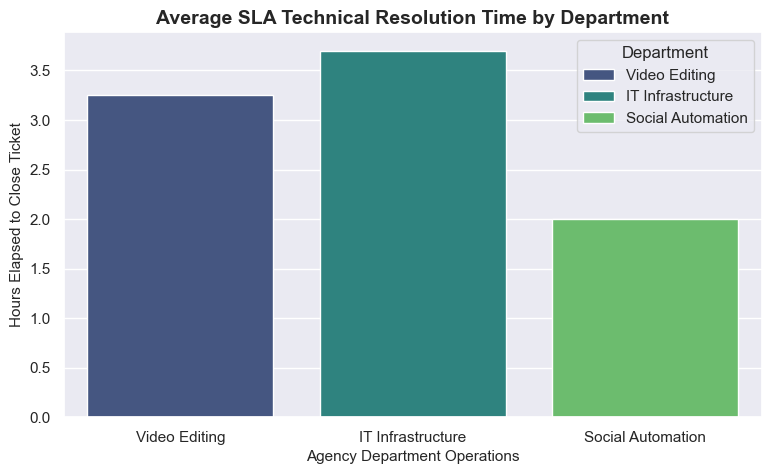

In [21]:
sns.set_theme(style = 'darkgrid')
plt.figure(figsize = (9,5))
sns.barplot(
    data = df_tickets,
    x = 'Department',
    y = 'Resolution_Time_Hours',
    hue = 'Department',
    palette = 'viridis',
    legend = True, # Shows what different color bars are representing.
    errorbar = None
)

plt.title('Average SLA Technical Resolution Time by Department', fontsize=14, fontweight='bold')
plt.xlabel('Agency Department Operations', fontsize=11)
plt.ylabel('Hours Elapsed to Close Ticket', fontsize=11)
plt.show()

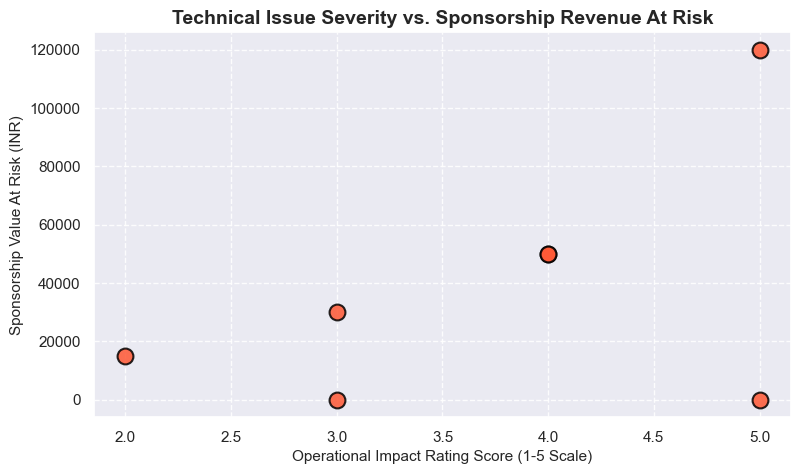

In [24]:
plt.figure(figsize=(9, 5))
plt.scatter(
    df_tickets['Impact_Score_1to5'], 
    df_tickets['Sponsorship_At_Risk_INR'], 
    color='#FF5733',  
    s=130, # Size of dots
    alpha=0.85, # Opacity of dots    
    edgecolor='black', 
    linewidth=1.5
)

plt.title('Technical Issue Severity vs. Sponsorship Revenue At Risk', fontsize=14, fontweight='bold')
plt.xlabel('Operational Impact Rating Score (1-5 Scale)', fontsize=11)
plt.ylabel('Sponsorship Value At Risk (INR)', fontsize=11)

# Draw clean structural grid background lines
plt.grid(True, linestyle='--', alpha=0.9)
plt.show()